In [ ]:
# Projeto: Inteligência Artificial - 07J 
# Previsão de Cancelamento de Clientes (Churn) no Setor de Telecomunicações utilizando Machine Learning


# Integrantes do Grupo:
# - Guilherme Soares (RA: 10428380)
# - Isabella Sofia Martins (RA: 10420398)
# - Lucas César Kato (RA: 10419319)


# Síntese do Conteúdo: 
# Este arquivo contém a Análise Exploratória de Dados (EDA) e a fase de preparação de dados estruturados utilizando o dataset 'Telco Customer Churn'.
# As etapas incluem limpeza de dados, análise de variáveis, geração de gráficos para identificação de padrões de cancelamento e preparação com One-Hot Encoding.


# Histórico de Alterações:
# 14/09/2026: Isabella Sofia Martins - carregamento dos dados brutos e tratamento inicial 
# 14/09/2026: Isabella Sofia Martins - criação das visualizações gráficas e matrizes de correlação
# 14/09/2026: Isabella Sofia Martins - aplicação de one-hot encoding e normalização


<h3> 1. Instalação e import de bibliotecas necessárias </h3> 
<p> execute uma linha por vez no bloco abaixo para realizar as instalações se não tiver as bibliotecas em seu ambiente - caso contrário, importe as bibliotecas no próximo bloco.</p>


In [92]:
#pip install matplotlib
#pip install seaborn
#pip install scikit-learn
#pip install pandas 
#pip install numpy

In [ ]:
# importação das libs 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

<h3> 2. Limpeza e tratamento da base inicial </h3>

In [93]:
# 1. carregamento do arquivo substituindo as vírgulas por colunas
df = pd.read_csv('telecom_customers_churn.csv', sep=',', quoting=csv.QUOTE_NONE)

# 2. limpa as aspas que ficaram nos nomes das colunas e nos dados
df.columns = df.columns.str.replace('"', '')

# 3. tratamento da coluna TotalCharges: tem espaços em branco onde deveriam ser números
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True) #remove as linhas que ficaram vazias após a conversão

for coluna in df.columns:
    if df[coluna].dtype == 'object': #se a coluna for texto
        df[coluna] = df[coluna].str.replace('"', '')

# 4. visualizaçao do resultado (agora deve estar separado em 21 colunas perfeitamente)
print(f"Total de Linhas e Colunas: {df.shape}")
display(df.head())

Total de Linhas e Colunas: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<h3> 3. Analise Exploratória de Dados (EDA) </h3>

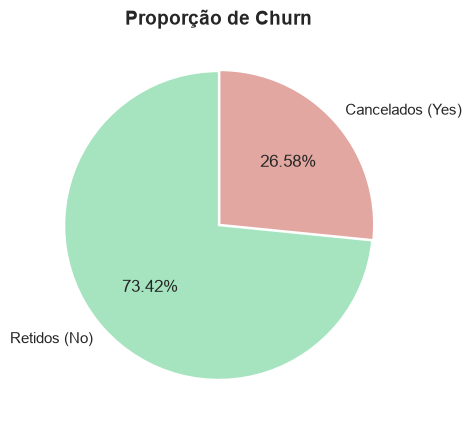

In [95]:
#config visual para os gráficos
sns.set_theme(style="whitegrid")

# Gráfico 1: Proporção total do Churn
plt.figure(figsize=(5, 5))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=['Retidos (No)', 'Cancelados (Yes)'], autopct='%0.2f%%',  colors=["#a6e4c0", "#e2a7a0"], startangle=90, explode=(0, 0.01), shadow=False)
plt.title('Proporção de Churn', fontsize=14, fontweight='bold')
plt.savefig('grafico_01_proporcao_churn.png', bbox_inches='tight')
plt.show()

<h3> Grafico de Densidade (KDE): </h3>

<p> O modelo abaixo indica que os 5 primeiros meses são a zona crítica onde a operadora mais perde clientes. Campanhas de fidelização devem focar nesse período de integração (onboarding). </p>

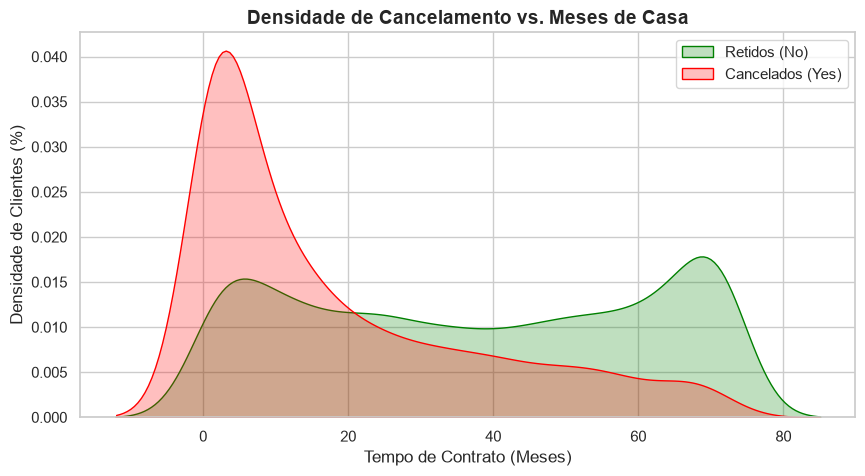

In [54]:
# Gráfico 2: Cancelamento vs. Tempo de Contrato (Tenure)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['Churn'] == 'No'], x='tenure', fill=True, color="green", label='Retidos (No)')
sns.kdeplot(data=df[df['Churn'] == 'Yes'], x='tenure', fill=True, color="red", label='Cancelados (Yes)')
plt.title('Densidade de Cancelamento vs. Meses de Casa', fontsize=14, fontweight='bold')
plt.xlabel('Tempo de Contrato (Meses)')
plt.ylabel('Densidade de Clientes (%)')
plt.legend()
plt.savefig('grafico_02_densidade_tempo.png', bbox_inches='tight')
plt.show()

<h3> Mensalidade vs. Tipo de Contrato </h3>
<p> Apesar de todas as modalidades de contrato possuirem maior evasão ao pagarem mensalidades mais caras, clientes no contrato mês a mês (month-to-month) e que pagam mensalidades altas concentram o maior volume absoluto de saída. Com isso, surge a forte hipótese da qualidade do produto fornecido a maior preço não apresentar um bom custo-benefício em relação aos planos básicos (mais baratos). </p>

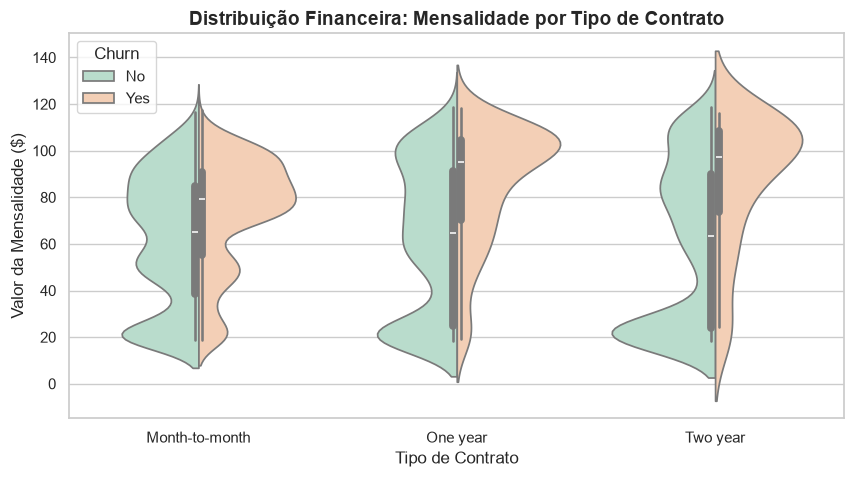

In [88]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn', split=True, palette='Pastel2')
plt.title('Distribuição Financeira: Mensalidade por Tipo de Contrato', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Valor da Mensalidade ($)')
plt.savefig('grafico_03_perfil_risco.png', bbox_inches='tight')
plt.show()

<h3> Cancelamentos por Tempo de Contrato </h3>

<p> No gráfico abaixo é possível concluir que a taxa de cancelamento é muito maior no plano mensal (desconsiderando custos entre planos de um mesmo ternure). </p>

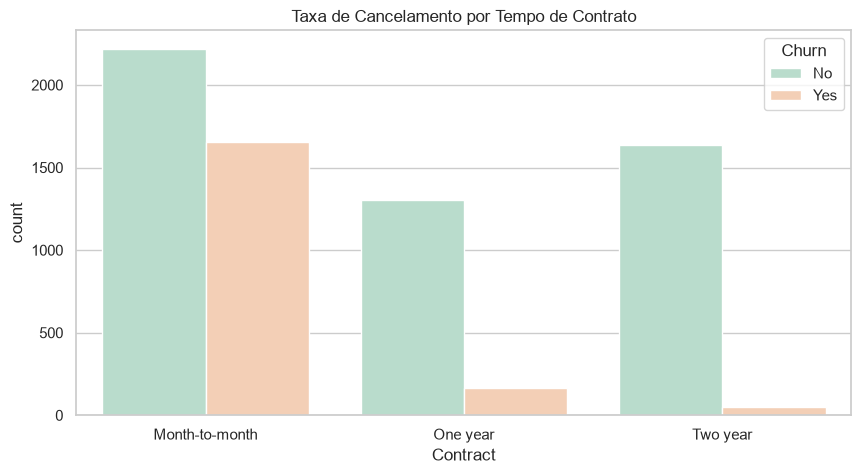

In [94]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Pastel2')
plt.title('Taxa de Cancelamento por Tempo de Contrato')
plt.savefig('grafico_04_contrato.png')
plt.show()


<h3> 4. Preparação da base para o modelo de Machine Learning </h3>

In [70]:
# 4. PREPARAÇÃO PARA O MODELO DE MACHINE LEARNING
# One-Hot Encoding: Transforma as colunas de texto (Ex: InternetService) em colunas de 0 e 1
df_preparado = pd.get_dummies(df, drop_first=True)

# Normalização: Coloca os valores financeiros e de meses na mesma escala matemática
scaler = MinMaxScaler()
colunas_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_preparado[colunas_numericas] = scaler.fit_transform(df_preparado[colunas_numericas])


display(df_preparado.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,0.000000,0.115423,0.001275,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,0.464789,0.385075,0.215867,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,0.014085,0.354229,0.010310,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,0.619718,0.239303,0.210241,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,0.014085,0.521891,0.015330,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True
